# splitQP

A tiny JAX solver for **families** of dense convex quadratic programs that share
a fixed quadratic and constraint matrix

$$\min_x\ \tfrac12 x^\top P x + q^\top x \quad\text{s.t.}\quad l \le A x \le u,\qquad P\succeq0.$$

It is proximal ADMM: `Solver(P, A)` forms and factors one matrix, and that single
Cholesky serves every iteration and every member of the family while $q$, $l$, $u$
vary. This notebook builds a small ordered family and solves it three ways from
one factorization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import splitqp

## One fixed $(P, A)$, a moving family

`P` and `A` are fixed. Member $i$ tracks a moving centre $x(t_i)$: the box brackets
$A\,x(t_i)$ and $q$ pulls toward $x(t_i)$, so adjacent members have nearby optima
(good for warm starts).

In [2]:
rng = np.random.default_rng(0)
n, m, B = 8, 12, 24
M = rng.normal(size=(n, n))
P = M @ M.T + n * np.eye(n)                  # fixed, symmetric positive definite
A = rng.normal(size=(m, n)); A /= np.linalg.norm(A, axis=1, keepdims=True)

x0, dx = rng.normal(size=n), rng.normal(size=n)
width = rng.uniform(0.3, 0.8, size=m)
t = np.linspace(0.0, 1.0, B)                 # the ordered family parameter
qs = np.zeros((B, n)); ls = np.zeros((B, m)); us = np.zeros((B, m))
for i, ti in enumerate(t):
    xc = x0 + ti * dx
    c = A @ xc
    ls[i], us[i] = c - width, c + width
    qs[i] = -(P @ xc)

solver = splitqp.Solver(P, A)                # the one factorization

In [3]:
scalar = solver.solve(qs[0], ls[0], us[0])          # one member
batch = solver.solve_batch(qs, ls, us)               # all members, independent
seq = solver.solve_sequence(qs, ls, us)              # all members, ordered warm sequence

xb, xq = np.asarray(batch.x), np.asarray(seq.x)
print("family size            ", B)
print("factorizations         ", solver.factorizations, " (shared by every mode)")
print("scalar vs batch[0] diff ", f"{np.max(np.abs(np.asarray(scalar.x) - xb[0])):.1e}")
print("batch vs sequence diff  ", f"{np.max(np.abs(xb - xq)):.1e}")
print("iterations: batch total ", int(np.asarray(batch.iterations).sum()),
      " sequence total", int(np.asarray(seq.iterations).sum()))

family size             24
factorizations          1  (shared by every mode)
scalar vs batch[0] diff  2.2e-16
batch vs sequence diff   4.0e-06
iterations: batch total  656  sequence total 495


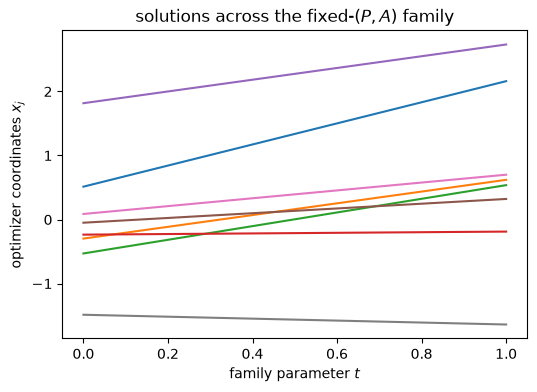

In [4]:
# how the optimizer moves along the family parameter
fig, ax = plt.subplots(figsize=(6, 4))
for j in range(n):
    ax.plot(t, xb[:, j], lw=1.5)
ax.set_xlabel("family parameter $t$"); ax.set_ylabel("optimizer coordinates $x_j$")
ax.set_title("solutions across the fixed-$(P, A)$ family")
plt.show()

In [5]:
# an illustrative local timing (compile is included in the first call)
import time
def wall(fn):
    fn(); t0 = time.perf_counter()               # one untimed warm-up
    jax.block_until_ready(fn().x); return 1e3 * (time.perf_counter() - t0)

def py_warm():
    state = None
    for i in range(B):
        r = solver.solve(qs[i], ls[i], us[i], init=state); state = r.state
    return r
print(f"python warm loop : {wall(py_warm):7.1f} ms total")
print(f"solve_sequence   : {wall(lambda: solver.solve_sequence(qs, ls, us)):7.1f} ms total")
print(f"solve_batch      : {wall(lambda: solver.solve_batch(qs, ls, us)):7.1f} ms total")

python warm loop :    65.9 ms total
solve_sequence   :     1.8 ms total
solve_batch      :     2.6 ms total


`solve_batch` treats the members independently; `solve_sequence` follows the
ordered, warm-started family as one compiled `jax.lax.scan`; and `solve` warm-started
from the previous result is the same sequence dispatched from Python. All three
reuse the single construction-time factorization.